# Exercice 7 
Calculez la densité de chaque état du Brésil, puis projetez la dans une Choroplèthe aux valeurs discrétisées.     
csv sur le Brésil : ```DATA/pop_br.csv```    
Contours du Brésil : ```DATA/br.json```    

1- Lire les fichiers    
2- Faire une jointure    
3- Calculer la superficie des états    
4- Calculer la densité des états    
5- Discrétiser les valeurs continues    
6- Projeter sur une carte    

In [65]:
# Import des bibliothèques
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1- Lire les fichiers
df = pd.read_csv("./DATA/pop_br.csv", sep=",", encoding="utf-8")
gdf = gpd.read_file("./DATA/br.json")

In [66]:
display(df)
display(gdf)

,name,pop
0,Rondônia,1751950
1,Acre,884372
2,Amazonas,4321616
3,Roraima,738772
4,Pará,8711196
5,Amapá,806517
6,Tocantins,1586859
7,Maranhão,7018211
8,Piauí,3384547
9,Ceará,9268836


,source,id,name,geometry
0,https://simplemaps.com,BRRS,Rio Grande do Sul,"POLYGON ((-53.84201 -27.16351, -53.84084 -27.1..."
1,https://simplemaps.com,BRRR,Roraima,"POLYGON ((-58.97202 1.31231, -58.87051 0.22536..."
2,https://simplemaps.com,BRPA,Pará,"MULTIPOLYGON (((-58.87051 0.22536, -58.97202 1..."
3,https://simplemaps.com,BRAC,Acre,"POLYGON ((-73.80676 -7.11788, -73.79442 -7.122..."
4,https://simplemaps.com,BRAP,Amapá,"MULTIPOLYGON (((-51.90831 -1.15797, -51.90884 ..."
5,https://simplemaps.com,BRMS,Mato Grosso do Sul,"POLYGON ((-57.72446 -17.73664, -57.71403 -17.7..."
6,https://simplemaps.com,BRPR,Paraná,"MULTIPOLYGON (((-54.24575 -24.05039, -54.20483..."
7,https://simplemaps.com,BRSC,Santa Catarina,"MULTIPOLYGON (((-49.71353 -29.32448, -49.72748..."
8,https://simplemaps.com,BRAM,Amazonas,"POLYGON ((-63.38655 2.23589, -63.37961 2.22889..."
9,https://simplemaps.com,BRRO,Rondônia,"POLYGON ((-66.64892 -9.91588, -66.83051 -9.837..."


In [67]:
gdf_tot= gdf.merge(df, on="name").to_crs(3857)

In [68]:
display(gdf_tot)
gdf_tot.crs

,source,id,name,geometry,pop
0,https://simplemaps.com,BRRS,Rio Grande do Sul,"POLYGON ((-5993664.689 -3143914.906, -5993534....",11233263
1,https://simplemaps.com,BRRR,Roraima,"POLYGON ((-6564735.756 146098.6, -6553435.153 ...",738772
2,https://simplemaps.com,BRPA,Pará,"MULTIPOLYGON (((-6553435.153 25087.161, -65647...",8711196
3,https://simplemaps.com,BRAC,Acre,"POLYGON ((-8216131.18 -794404.701, -8214757.25...",884372
4,https://simplemaps.com,BRAP,Amapá,"MULTIPOLYGON (((-5778407.147 -128913.729, -577...",806517
5,https://simplemaps.com,BRMS,Mato Grosso do Sul,"POLYGON ((-6425857.086 -2006745.885, -6424696....",2924631
6,https://simplemaps.com,BRPR,Paraná,"MULTIPOLYGON (((-6038609.25 -2759549.957, -603...",11890517
7,https://simplemaps.com,BRSC,Santa Catarina,"MULTIPOLYGON (((-5534084.961 -3417009.83, -553...",8187029
8,https://simplemaps.com,BRAM,Amazonas,"POLYGON ((-7056158.018 248961.211, -7055385.40...",4321616
9,https://simplemaps.com,BRRO,Rondônia,"POLYGON ((-7419324.339 -1109382.474, -7439538....",1751950


<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [69]:
gdf_tot["superficie"]=gdf_tot.geometry.area / 1_000_000

In [70]:
gdf_tot

,source,id,name,geometry,pop,superficie
0,https://simplemaps.com,BRRS,Rio Grande do Sul,"POLYGON ((-5993664.689 -3143914.906, -5993534....",11233263,3.626317e+05
1,https://simplemaps.com,BRRR,Roraima,"POLYGON ((-6564735.756 146098.6, -6553435.153 ...",738772,2.262414e+05
2,https://simplemaps.com,BRPA,Pará,"MULTIPOLYGON (((-6553435.153 25087.161, -65647...",8711196,1.248645e+06
3,https://simplemaps.com,BRAC,Acre,"POLYGON ((-8216131.18 -794404.701, -8214757.25...",884372,1.591653e+05
4,https://simplemaps.com,BRAP,Amapá,"MULTIPOLYGON (((-5778407.147 -128913.729, -577...",806517,1.402625e+05
5,https://simplemaps.com,BRMS,Mato Grosso do Sul,"POLYGON ((-6425857.086 -2006745.885, -6424696....",2924631,4.073312e+05
6,https://simplemaps.com,BRPR,Paraná,"MULTIPOLYGON (((-6038609.25 -2759549.957, -603...",11890517,2.415796e+05
7,https://simplemaps.com,BRSC,Santa Catarina,"MULTIPOLYGON (((-5534084.961 -3417009.83, -553...",8187029,1.208137e+05
8,https://simplemaps.com,BRAM,Amazonas,"POLYGON ((-7056158.018 248961.211, -7055385.40...",4321616,1.588152e+06
9,https://simplemaps.com,BRRO,Rondônia,"POLYGON ((-7419324.339 -1109382.474, -7439538....",1751950,2.484810e+05


In [71]:
gdf_tot["densite"]=gdf_tot["pop"]/gdf_tot["superficie"]
display(gdf_tot)

,source,id,name,geometry,pop,superficie,densite
0,https://simplemaps.com,BRRS,Rio Grande do Sul,"POLYGON ((-5993664.689 -3143914.906, -5993534....",11233263,3.626317e+05,30.977057
1,https://simplemaps.com,BRRR,Roraima,"POLYGON ((-6564735.756 146098.6, -6553435.153 ...",738772,2.262414e+05,3.265415
2,https://simplemaps.com,BRPA,Pará,"MULTIPOLYGON (((-6553435.153 25087.161, -65647...",8711196,1.248645e+06,6.976521
3,https://simplemaps.com,BRAC,Acre,"POLYGON ((-8216131.18 -794404.701, -8214757.25...",884372,1.591653e+05,5.556311
4,https://simplemaps.com,BRAP,Amapá,"MULTIPOLYGON (((-5778407.147 -128913.729, -577...",806517,1.402625e+05,5.750056
5,https://simplemaps.com,BRMS,Mato Grosso do Sul,"POLYGON ((-6425857.086 -2006745.885, -6424696....",2924631,4.073312e+05,7.179983
6,https://simplemaps.com,BRPR,Paraná,"MULTIPOLYGON (((-6038609.25 -2759549.957, -603...",11890517,2.415796e+05,49.219876
7,https://simplemaps.com,BRSC,Santa Catarina,"MULTIPOLYGON (((-5534084.961 -3417009.83, -553...",8187029,1.208137e+05,67.765737
8,https://simplemaps.com,BRAM,Amazonas,"POLYGON ((-7056158.018 248961.211, -7055385.40...",4321616,1.588152e+06,2.721160
9,https://simplemaps.com,BRRO,Rondônia,"POLYGON ((-7419324.339 -1109382.474, -7439538....",1751950,2.484810e+05,7.050639


In [72]:
gdf_tot["classe_dens"]=pd.qcut(
    gdf_tot["densite"],
    4,
    labels=["Q1","Q2","Q3","Q4"] 
)

In [73]:
gdf_tot

,source,id,name,geometry,pop,superficie,densite,classe_dens
0,https://simplemaps.com,BRRS,Rio Grande do Sul,"POLYGON ((-5993664.689 -3143914.906, -5993534....",11233263,3.626317e+05,30.977057,Q2
1,https://simplemaps.com,BRRR,Roraima,"POLYGON ((-6564735.756 146098.6, -6553435.153 ...",738772,2.262414e+05,3.265415,Q1
2,https://simplemaps.com,BRPA,Pará,"MULTIPOLYGON (((-6553435.153 25087.161, -65647...",8711196,1.248645e+06,6.976521,Q1
3,https://simplemaps.com,BRAC,Acre,"POLYGON ((-8216131.18 -794404.701, -8214757.25...",884372,1.591653e+05,5.556311,Q1
4,https://simplemaps.com,BRAP,Amapá,"MULTIPOLYGON (((-5778407.147 -128913.729, -577...",806517,1.402625e+05,5.750056,Q1
5,https://simplemaps.com,BRMS,Mato Grosso do Sul,"POLYGON ((-6425857.086 -2006745.885, -6424696....",2924631,4.073312e+05,7.179983,Q2
6,https://simplemaps.com,BRPR,Paraná,"MULTIPOLYGON (((-6038609.25 -2759549.957, -603...",11890517,2.415796e+05,49.219876,Q3
7,https://simplemaps.com,BRSC,Santa Catarina,"MULTIPOLYGON (((-5534084.961 -3417009.83, -553...",8187029,1.208137e+05,67.765737,Q3
8,https://simplemaps.com,BRAM,Amazonas,"POLYGON ((-7056158.018 248961.211, -7055385.40...",4321616,1.588152e+06,2.721160,Q1
9,https://simplemaps.com,BRRO,Rondônia,"POLYGON ((-7419324.339 -1109382.474, -7439538....",1751950,2.484810e+05,7.050639,Q2


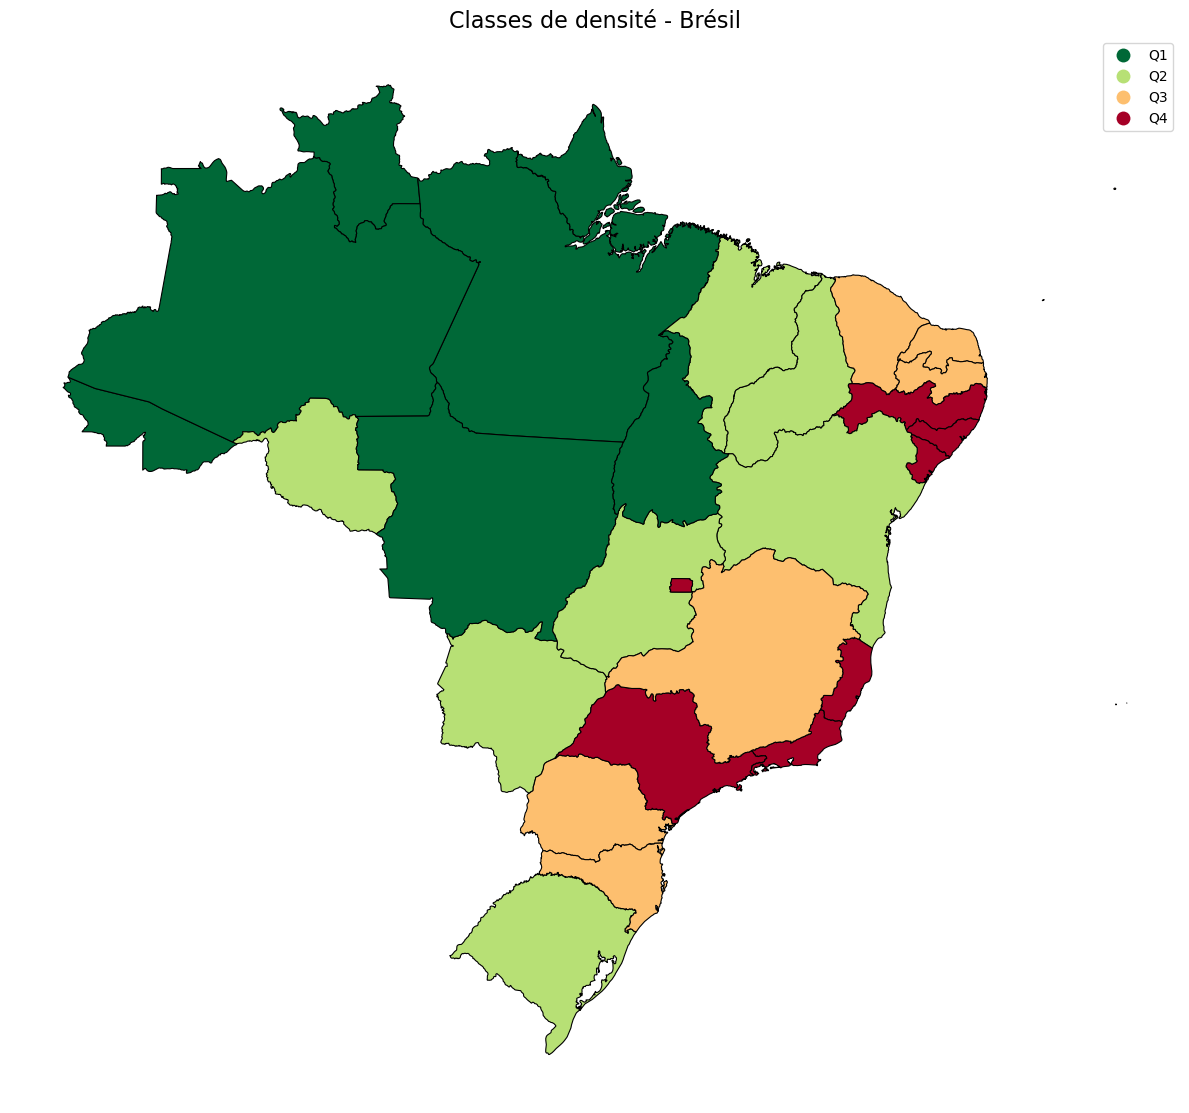

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf_tot.plot(
    column='classe_dens',     # On plot sur la colonne "classe_desn" qu'on vient de créer
    categorical=True,        # Ici n'est pas nécessaire, mais permet d'indiquer à gpd que les valeurs sont discrètes
    legend=True,             #affiche la légende
    edgecolor='black',       # contours des polygones en noir
    linewidth=0.8,           # épaisseur des contours
    cmap='RdYlGn_r',         # Inversé → _r à la fin : rouge = forte densité
    ax=ax                    # On plot sur ax
)

plt.title("Classes de densité - Brésil", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

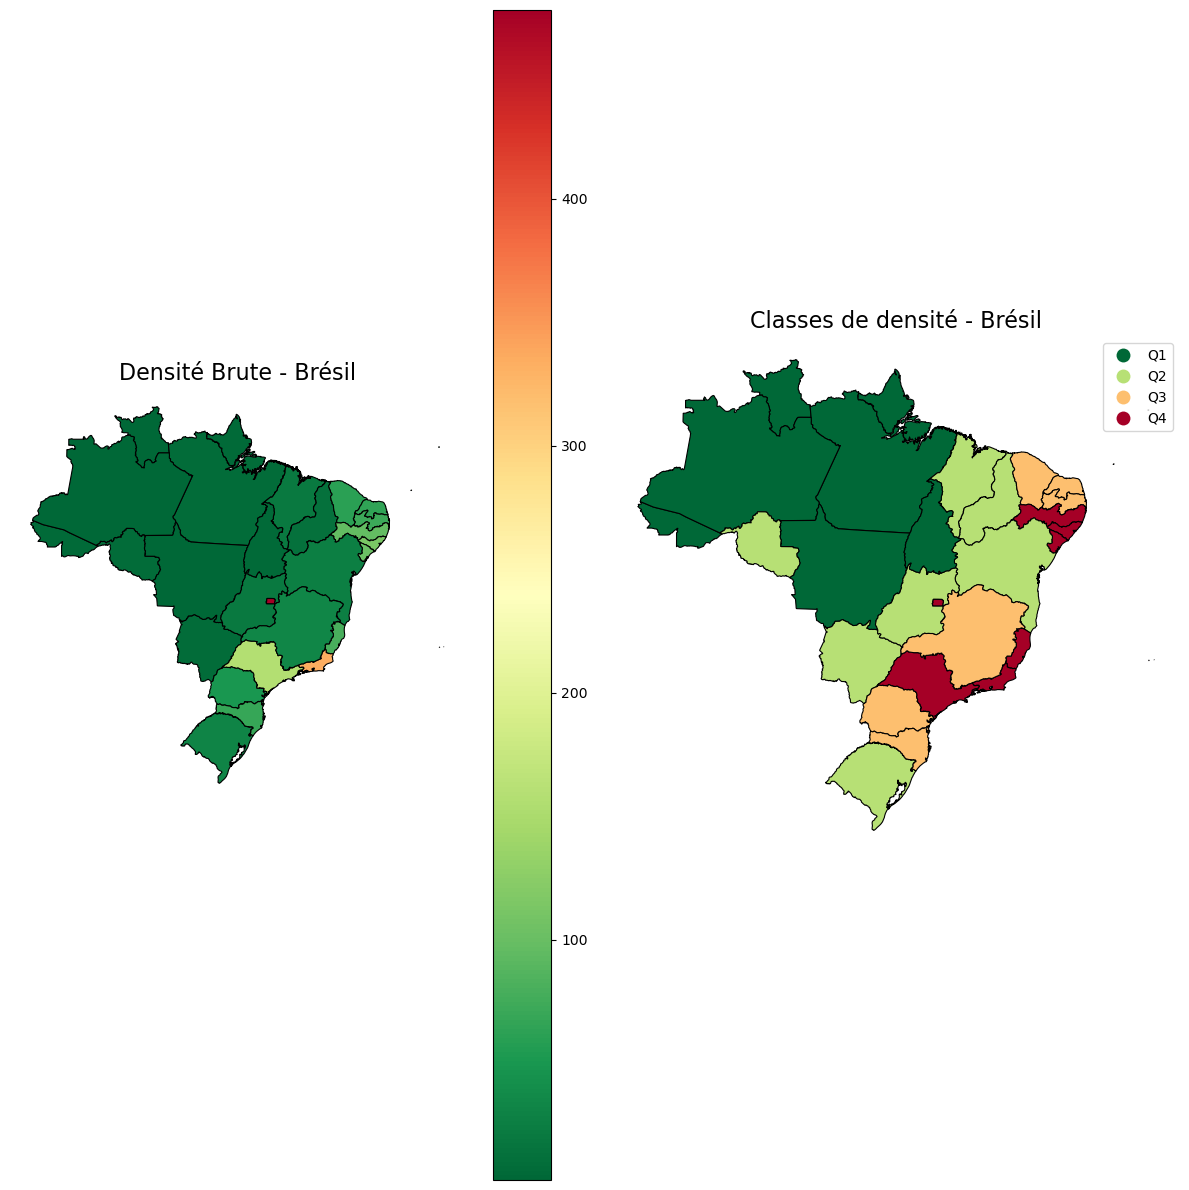

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

gdf_tot.plot(
    column='densite',     # On plot sur la colonne "classe_desn" qu'on vient de créer    # Ici n'est pas nécessaire, mais permet d'indiquer à gpd que les valeurs sont discrètes
    legend=True,             #affiche la légende
    edgecolor='black',       # contours des polygones en noir
    linewidth=0.8,           # épaisseur des contours
    cmap='RdYlGn_r',         # Inversé → _r à la fin : rouge = forte densité
    ax=ax[0]                    # On plot sur ax
)
ax[0].set_title("Densité Brute - Brésil", fontsize=16)
ax[0].axis('off')

gdf_tot.plot(
    column='classe_dens',     # On plot sur la colonne "classe_desn" qu'on vient de créer    # Ici n'est pas nécessaire, mais permet d'indiquer à gpd que les valeurs sont discrètes
    legend=True,
    categorical = True,
    edgecolor='black',       # contours des polygones en noir
    linewidth=0.8,           # épaisseur des contours
    cmap='RdYlGn_r',         # Inversé → _r à la fin : rouge = forte densité
    ax=ax[1]                    # On plot sur ax
)
ax[1].set_title("Classes de densité - Brésil", fontsize=16)
ax[1].axis('off')


plt.tight_layout()
plt.show()